# Create an Interface with ZSL and Relax it with MACE

Use Zur and McGill superlattices matching [algorithm](https://doi.org/10.1063/1.3330840) to create interfaces between two materials using the `mat3ra-made` [implementation](https://github.com/Exabyte-io/made).

<h2 style="color:green">Usage</h2>

1. Drop the materials files into the "uploads" folder in the JupyterLab file browser
1. Set Input Parameters below or use the default values
1. Click "Run" > "Run All" to run all cells
1. Wait for the run to complete. Scroll down to view cell results.
1. Review the strain plot and modify parameters as needed

## Methodology

1. Load materials from JSON files and create substrate and film slabs via `mat3ra-made`
2. Run ZSL strain matching and plot strain vs interface area
3. Create the selected interface and convert to ASE atoms with `to_ase()`
4. Relax the interface with MACE-MP-0 and visualize convergence
5. Compute interface binding energy decomposition

## 1. Set Input Parameters

### 1.1. Substrate and Film Materials

In [215]:

SUBSTRATE_NAME = "Nickel"
FILM_NAME = "Graphene"
SUBSTRATE_INDEX = 0
FILM_INDEX = 1

### 1.2. Slab Parameters

In [216]:
SUBSTRATE_MILLER_INDICES = (1, 1, 1)
SUBSTRATE_THICKNESS = 6  # in atomic layers
SUBSTRATE_TERMINATION_FORMULA = None  # if None, the first termination is used

FILM_MILLER_INDICES = (0, 0, 1)
FILM_THICKNESS = 1  # in atomic layers
FILM_TERMINATION_FORMULA = None  # if None, the first termination is used

USE_CONVENTIONAL_CELL = True

### 1.3. Interface and Relaxation Parameters

In [217]:
INTERFACE_DISTANCE = None  # gap between substrate and film, in Angstrom, if None, the distance will be set to the sum of the covalent radii of the two materials
INTERFACE_VACUUM = 10.0  # vacuum over film, in Angstrom
REDUCE_RESULT_CELL_TO_PRIMITIVE = True

MAX_AREA = 150  # in Angstrom^2
MAX_AREA_TOLERANCE = 0.09
MAX_LENGTH_TOLERANCE = 0.05
MAX_ANGLE_TOLERANCE = 0.02

RELAXATION_PARAMETERS = {
    "FMAX": 0.01,
}
MACE_MODEL = "large"  # "small", "medium", or "large" MACE-MP-0 foundation model

## 2. Install Packages

In [218]:
# !pip install mat3ra-made torch "mace-torch" ase "e3nn==0.4.4" "numpy<=1.26.4" pymatgen

## 3. Load Materials

In [219]:
from mat3ra.made.material import Material
from mat3ra.standata.materials import Materials

substrate = Material.create(Materials.get_by_name_first_match(SUBSTRATE_NAME))
film = Material.create(Materials.get_by_name_first_match(FILM_NAME))

print("Substrate:", substrate.name)
print("Film:     ", film.name)

Substrate: Ni, Nickel, FCC (Fm-3m) 3D (Bulk), mp-23
Film:      C, Graphene, HEX (P6/mmm) 2D (Monolayer), 2dm-3993


### 3.1. Visualize Input Materials

In [220]:
from utils.visualize import visualize_materials as visualize

visualize([substrate, film], repetitions=[3, 3, 1], rotation="0x")

GridBox(children=(VBox(children=(Label(value='Ni - Material - rotation: 0x', layout=Layout(align_self='center'…

## 3.2. Calculate nearest neighbor distance for each material to inform interface distance choice


First RDF peak for substrate (Ni, Nickel, FCC (Fm-3m) 3D (Bulk), mp-23): 2.450 Å
First RDF peak for film (C, Graphene, HEX (P6/mmm) 2D (Monolayer), 2dm-3993): 1.450 Å
Setting interface distance to 1.950 Å based on RDF peaks


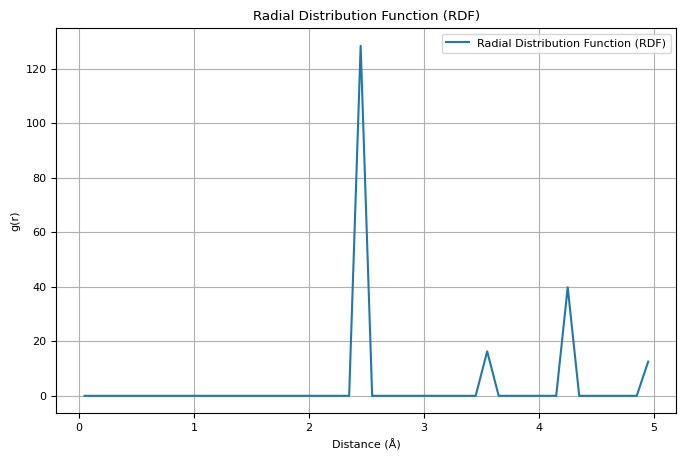

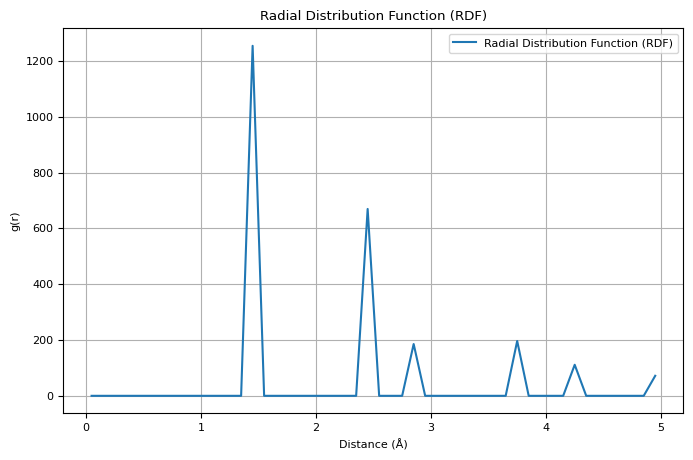

In [221]:
from mat3ra.made.tools.build_components.entities.reusable.three_dimensional.supercell.helpers import create_supercell
from mat3ra.made.tools.analyze.rdf import RadialDistributionFunction
### 7.3. Plot Radial Distribution Functions
from utils.plot import plot_rdf

substrate_supercell = create_supercell(substrate, scaling_factor=[3, 3, 3])
film_supercell = create_supercell(film, scaling_factor=[3, 3, 3])

rdf_substrate = RadialDistributionFunction.from_material(substrate_supercell, cutoff=5.0)
rdf_film = RadialDistributionFunction.from_material(film_supercell, cutoff=5.0)

first_peak_substrate = rdf_substrate.first_peak_distance
first_peak_film = rdf_film.first_peak_distance

print(f"First RDF peak for substrate ({substrate.name}): {first_peak_substrate:.3f} Å")
print(f"First RDF peak for film ({film.name}): {first_peak_film:.3f} Å")

if INTERFACE_DISTANCE is None:
    INTERFACE_DISTANCE = (first_peak_substrate + first_peak_film) / 2
    print(f"Setting interface distance to {INTERFACE_DISTANCE:.3f} Å based on RDF peaks")

plot_rdf(substrate_supercell, cutoff=5.0)
plot_rdf(film_supercell, cutoff=5.0)

## 4. Configure Slabs

### 4.1. Get Possible Terminations

In [222]:
from mat3ra.made.tools.helpers import get_slab_terminations

film_slab_terminations = get_slab_terminations(material=film, miller_indices=FILM_MILLER_INDICES)
substrate_slab_terminations = get_slab_terminations(material=substrate, miller_indices=SUBSTRATE_MILLER_INDICES)
print("Film slab terminations:     ", film_slab_terminations)
print("Substrate slab terminations:", substrate_slab_terminations)

Film slab terminations:      [C_P6/mmm_2]
Substrate slab terminations: [Ni_R-3m_4]


/Users/mat3ra/code/GREEN/api-examples/.venv-3.11.2/lib/python3.11/site-packages/pymatgen/symmetry/analyzer.py:213: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  n = self._space_group_data["number"]
/Users/mat3ra/code/GREEN/api-examples/.venv-3.11.2/lib/python3.11/site-packages/pymatgen/core/surface.py:952: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  initial_structure.add_site_property("bulk_wyckoff", spg_analyzer.get_symmetry_dataset()["wyckoffs"])


### 4.2. Visualize Slabs for All Possible Terminations

In [223]:
from mat3ra.made.tools.helpers import create_slab, select_slab_termination
from mat3ra.made.tools.helpers import create_interface_zsl_between_slabs

film_slabs = [
    create_slab(film, miller_indices=FILM_MILLER_INDICES, termination_top=t, vacuum=0)
    for t in film_slab_terminations
]
substrate_slabs = [
    create_slab(substrate, miller_indices=SUBSTRATE_MILLER_INDICES, termination_top=t, vacuum=0, number_of_layers=4)
    for t in substrate_slab_terminations
]

visualize(
    [{"material": s, "title": str(t)} for s, t in zip(film_slabs, film_slab_terminations)],
    repetitions=[3, 3, 1], rotation="-90x",
)
visualize(
    [{"material": s, "title": str(t)} for s, t in zip(substrate_slabs, substrate_slab_terminations)],
    repetitions=[3, 3, 1], rotation="-90x",
)

GridBox(children=(VBox(children=(Label(value='C2 - C_P6/mmm_2 - rotation: -90x', layout=Layout(align_self='cen…

GridBox(children=(VBox(children=(Label(value='Ni16 - Ni_R-3m_4 - rotation: -90x', layout=Layout(align_self='ce…

### 4.3. Create Substrate and Film Slabs

In [224]:
from mat3ra.made.tools.build.pristine_structures.two_dimensional.slab import SlabConfiguration, SlabBuilder

substrate_slab_config = SlabConfiguration.from_parameters(
    material_or_dict=substrate,
    miller_indices=SUBSTRATE_MILLER_INDICES,
    number_of_layers=SUBSTRATE_THICKNESS,
    vacuum=0.0,
    termination_top_formula=SUBSTRATE_TERMINATION_FORMULA,
    use_conventional_cell=USE_CONVENTIONAL_CELL,
)
film_slab_config = SlabConfiguration.from_parameters(
    material_or_dict=film,
    miller_indices=FILM_MILLER_INDICES,
    number_of_layers=FILM_THICKNESS,
    vacuum=0.0,
    termination_bottom_formula=FILM_TERMINATION_FORMULA,
    use_conventional_cell=USE_CONVENTIONAL_CELL,
)

substrate_slab = SlabBuilder().get_material(substrate_slab_config)
film_slab = SlabBuilder().get_material(film_slab_config)

## 5. Find Interfaces with ZSL Strain Matching

### 5.1. Initialize ZSL Analyzer

In [225]:
from mat3ra.made.tools.analyze.interface import ZSLInterfaceAnalyzer

zsl_analyzer = ZSLInterfaceAnalyzer(
    substrate_slab_configuration=substrate_slab_config,
    film_slab_configuration=film_slab_config,
    max_area=MAX_AREA,
    max_area_ratio_tol=MAX_AREA_TOLERANCE,
    max_length_tol=MAX_LENGTH_TOLERANCE,
    max_angle_tol=MAX_ANGLE_TOLERANCE,
    reduce_result_cell=False,
)

### 5.2. Generate and Plot Matches

In [226]:
from utils.plot import plot_strain_vs_area

PLOT_SETTINGS = {
    "HEIGHT": 600,
    "X_SCALE": "log",
    "Y_SCALE": "log",
}

matches = zsl_analyzer.zsl_match_holders
print(f"Found {len(matches)} matches")
plot_strain_vs_area(matches, PLOT_SETTINGS)

Found 72 matches


### 5.3. Select the Interface

Choose the match index from the plot above (index 0 has the lowest strain).

In [227]:
selected_index = 0

## 6. Create the Interface

In [228]:
interface = create_interface_zsl_between_slabs(
    substrate_slab=substrate_slab,
    film_slab=film_slab,
    gap=INTERFACE_DISTANCE,
    vacuum=INTERFACE_VACUUM,
    match_id=selected_index,
    max_area=MAX_AREA,
    max_area_ratio_tol=MAX_AREA_TOLERANCE,
    max_length_tol=MAX_LENGTH_TOLERANCE,
    max_angle_tol=MAX_ANGLE_TOLERANCE,
    reduce_result_cell_to_primitive=REDUCE_RESULT_CELL_TO_PRIMITIVE,
)

### 6.1. Visualize Interface

In [229]:
from utils.visualize import ViewersEnum

visualize([{"material": interface, "title": interface.name}], viewer=ViewersEnum.wave)
visualize(interface, repetitions=[1, 1, 1], rotation="-90x")

<IPython.core.display.Javascript object>

GridBox(children=(VBox(children=(Label(value='C2Ni6 - Material - rotation: -90x', layout=Layout(align_self='ce…

## 7. Apply Relaxation
### 7.1. Relax with MACE

In [ ]:
import plotly.graph_objs as go
from IPython.display import display
from plotly.subplots import make_subplots
from src.utils import ase_to_poscar
from mat3ra.made.tools.convert import to_ase
from ase.optimize import BFGS
from mace.calculators import mace_mp

calculator = mace_mp(model=MACE_MODEL, dispersion=True, default_dtype="float32", device="cpu")

ase_interface = to_ase(interface)
ase_interface.set_calculator(calculator)
dyn = BFGS(ase_interface)

steps = []
energies = []

fig = make_subplots(rows=1, cols=1, specs=[[{"type": "scatter"}]])
scatter = go.Scatter(x=[], y=[], mode="lines+markers", name="Energy")
fig.add_trace(scatter)
fig.update_layout(title_text="Real-time Optimization Progress", xaxis_title="Step", yaxis_title="Energy (eV)")

f = go.FigureWidget(fig)
display(f)


def plotly_callback():
    step = dyn.nsteps
    energy = ase_interface.get_total_energy()
    steps.append(step)
    energies.append(energy)
    print(f"Step: {step}, Energy: {energy:.4f} eV")
    with f.batch_update():
        f.data[0].x = steps
        f.data[0].y = energies


dyn.attach(plotly_callback, interval=1)
dyn.run(fmax=RELAXATION_PARAMETERS["FMAX"])

ase_original_interface = to_ase(interface)
ase_original_interface.set_calculator(calculator)
ase_final_interface = ase_interface

original_energy = ase_original_interface.get_total_energy()
relaxed_energy = ase_interface.get_total_energy()

print("Original structure:\n", ase_to_poscar(ase_original_interface))
print("\nRelaxed structure:\n", ase_to_poscar(ase_final_interface))
print(f"The final energy is {float(relaxed_energy):.3f} eV.")

Using Materials Project MACE for MACECalculator with /Users/mat3ra/.cache/mace/MACE_MPtrj_20229model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/Users/mat3ra/code/GREEN/api-examples/.venv-3.11.2/lib/python3.11/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


### 7.2. View Structure Before and After Relaxation

In [211]:
from mat3ra.made.tools.convert import from_ase


def atoms_to_material(atoms, title):
    material = Material.create(from_ase(atoms))
    material.name = title
    return material


material_original = atoms_to_material(ase_original_interface, f"Original  E={original_energy:.3f} eV")
material_relaxed = atoms_to_material(ase_final_interface, f"Relaxed  E={relaxed_energy:.3f} eV")

visualize(
    [
        {"material": material_original, "title": material_original.name},
        {"material": material_relaxed, "title": material_relaxed.name},
    ],
    viewer=ViewersEnum.wave,
)

GridBox(children=(HTML(value='\n    <h2>Original  E=-54.298 eV</h2>\n    <div id="wave-0-1775434260.9147468" s…

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7.4. Output interlayer distance before and after relaxation

In [212]:
from mat3ra.made.tools.analyze.other import get_average_interlayer_distance

print(f"Interlayer distance before relaxation: {get_average_interlayer_distance(material_original, 0, 1):.4f} Å")
print(f"Interlayer distance after relaxation:  {get_average_interlayer_distance(material_relaxed, 0, 1):.4f} Å")

Interlayer distance before relaxation: 1.9500 Å
Interlayer distance after relaxation:  1.9859 Å


### 7.4. Calculate Interface Energy

In [213]:
def filter_atoms_by_tag(atoms, material_index):
    return atoms[atoms.get_tags() == material_index]


def calculate_energy(atoms, calc):
    atoms.set_calculator(calc)
    return atoms.get_total_energy()


def calculate_delta_energy(total_energy, *component_energies):
    return total_energy - sum(component_energies)


substrate_original = filter_atoms_by_tag(ase_original_interface, SUBSTRATE_INDEX)
layer_original = filter_atoms_by_tag(ase_original_interface, FILM_INDEX)
substrate_relaxed = filter_atoms_by_tag(ase_final_interface, SUBSTRATE_INDEX)
layer_relaxed = filter_atoms_by_tag(ase_final_interface, FILM_INDEX)

original_substrate_energy = calculate_energy(substrate_original, calculator)
original_layer_energy = calculate_energy(layer_original, calculator)
relaxed_substrate_energy = calculate_energy(substrate_relaxed, calculator)
relaxed_layer_energy = calculate_energy(layer_relaxed, calculator)

delta_original = calculate_delta_energy(original_energy, original_substrate_energy, original_layer_energy)
delta_relaxed = calculate_delta_energy(relaxed_energy, relaxed_substrate_energy, relaxed_layer_energy)

area = ase_original_interface.get_volume() / ase_original_interface.cell[2, 2]
n_interface = ase_final_interface.get_global_number_of_atoms()
n_substrate = substrate_relaxed.get_global_number_of_atoms()
n_layer = layer_relaxed.get_global_number_of_atoms()
effective_delta_relaxed = (
                                  relaxed_energy / n_interface
                                  - (relaxed_substrate_energy / n_substrate + relaxed_layer_energy / n_layer)
                          ) / (2 * area)

print(f"Original Substrate energy: {original_substrate_energy:.4f} eV")
print(f"Relaxed Substrate energy:  {relaxed_substrate_energy:.4f} eV")
print(f"Original Layer energy:     {original_layer_energy:.4f} eV")
print(f"Relaxed Layer energy:      {relaxed_layer_energy:.4f} eV")
print("\nDelta between interface energy and sum of component energies")
print(f"Original Delta:            {delta_original:.4f} eV")
print(f"Relaxed Delta:             {delta_relaxed:.4f} eV")
print(f"Original Delta per area:   {delta_original / area:.4f} eV/Ang^2")
print(f"Relaxed Delta per area:    {delta_relaxed / area:.4f} eV/Ang^2")
print(f"Relaxed interface energy:  {relaxed_energy:.4f} eV")
print(
    f"Effective relaxed Delta per area: {effective_delta_relaxed:.4f} eV/Ang^2 ({effective_delta_relaxed / 0.16:.4f} J/m^2)")

/var/folders/wq/kjb0_d9126xd_3j3c13f7n9w0000gn/T/ipykernel_95667/1522852818.py:6: FutureWarning: Please use atoms.calc = calc
  atoms.set_calculator(calc)


Original Substrate energy: -35.6511 eV
Relaxed Substrate energy:  -35.6618 eV
Original Layer energy:     -18.5989 eV
Relaxed Layer energy:      -18.5988 eV

Delta between interface energy and sum of component energies
Original Delta:            -0.0484 eV
Relaxed Delta:             -0.0511 eV
Original Delta per area:   -0.0091 eV/Ang^2
Relaxed Delta per area:    -0.0096 eV/Ang^2
Relaxed interface energy:  -54.3117 eV
Effective relaxed Delta per area: 0.7943 eV/Ang^2 (4.9641 J/m^2)


## References

[1] mat3ra-made interface builder: https://github.com/Exabyte-io/made  
[2] MACE-MP-0 foundation model: https://github.com/ACEsuit/mace?tab=readme-ov-file#foundation-models  